# Reporte Científico: Simulación Comparativa del Rotor Magnético en MHD

Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

---

### Introducción y Marco Teórico

El problema del **Rotor Magnético de Balsara** es una prueba estandarizada fundamental en la astrofísica computacional para evaluar la robustez y precisión de los códigos magnetohidrodinámicos (MHD) ideados para simular plasmas astrofísicos (como discos de acreción o remanentes de supernova). 

El sistema físico consiste en un cilindro denso de fluido (el "rotor") que gira a alta velocidad en el plano $X-Y$, inmerso en un medio ambiente en reposo con menor densidad. Todo el dominio se encuentra bajo la influencia de un campo magnético inicialmente uniforme alineado en el eje $X$. A medida que pasa el tiempo, la rotación centrífuga estira las líneas de campo magnético, convirtiendo la energía cinética en energía magnética y térmica, lo que desencadena una serie compleja de ondas de choque MHD rápidas y lentas que se propagan hacia el exterior, deformando el rotor circular en una estructura elíptica.

Las ecuaciones ideales de la MHD en su forma de conservación hiperbólica son:

$$ \frac{\partial \mathbf{U}}{\partial t} + \frac{\partial \mathbf{F}}{\partial x} + \frac{\partial \mathbf{G}}{\partial y} = 0 $$

Donde el vector de variables conservadas $\mathbf{U}$ para la densidad $\rho$, el momento $\rho \mathbf{v}$, la energía total $E$ y el campo magnético $\mathbf{B}$ está dado por:

$$ \mathbf{U} = \left[ \rho, \rho v_x, \rho v_y, \rho v_z, E, B_x, B_y, B_z \right]^T $$

### Revisión del Estado del Arte

El problema del rotor magnético fue introducido originalmente por Balsara & Spicer (1999) como una prueba bidimensional rigurosa para evaluar la robustez y precisión de los esquemas numéricos al resolver las ecuaciones de la magnetohidrodinámica (MHD) ideal. A diferencia de problemas unidimensionales como el tubo de choque de Brio-Wu, el rotor magnético evalúa específicamente la capacidad de un código para mantener la restricción de divergencia nula del campo magnético ($\nabla \cdot \mathbf{B} = 0$) bajo una fuerte rotación y rápida propagación de ondas de Alfvén.

Históricamente, la incapacidad de controlar los errores de divergencia en este problema conducía a fuerzas paralelas al campo magnético espurias, resultando en inestabilidades numéricas y terminaciones prematuras de las simulaciones (Tóth, 2000). En la actualidad, códigos de vanguardia como PLUTO han estandarizado la solución de este problema mediante esquemas de captura de choques de alto orden acoplados con métodos de transporte restringido (Constrained Transport, CT) o limpieza de divergencia (Divergence Cleaning). La literatura reciente utiliza este problema de prueba no solo para validar esquemas espaciales, sino también para evaluar la disipación numérica en flujos fuertemente magnetizados, comparando aproximadores de Riemann como HLL, HLLD y Roe. El consenso en el estado del arte indica que el uso de fluxes difusivos (como Rusanov o Lax-Friedrichs) tiende a suavizar excesivamente las discontinuidades generadas por el rotor, mientras que los solvers tipo HLLD preservan mejor las ondas de Alfvén y las discontinuidades de contacto.

### Análisis Comparativo: PLUTO vs. Implementación en Python

### Objetivos del Reporte
1. Implementar un solver numérico bidimensional en Python utilizando el esquema de flujo de Rusanov (Lax-Friedrichs Local) y un integrador temporal TVD Runge-Kutta de segundo orden (RK2).
2. Ejecutar la misma configuración física en el código astrofísico avanzado **PLUTO** (simulación de referencia).
3. Realizar un análisis comparativo cualitativo (visualización de frentes de onda) y cuantitativo (cálculo de normas de error $L_1$ y $L_2$) para evaluar el efecto de la **difusión numérica** en esquemas de bajo orden.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pyPLUTO as pp
import os
import time

print("Entorno y librerías científicas cargadas con éxito.")

Entorno y librerías científicas cargadas con éxito.


## Metodología Numérica y Pipeline de Cómputo

A continuación se define el núcleo del código en Python. Se utiliza una malla estática y uniforme de $200 \times 200$ celdas en un dominio $[-0.5, 0.5] \times [-0.5, 0.5]$ con condiciones de contorno periódicas. 

El cálculo del flujo numérico en las interfaces de las celdas se realiza mediante el método de **Rusanov**:

$$ \mathbf{F}_{i+1/2} = \frac{1}{2}\left(\mathbf{F}_L + \mathbf{F}_R\right) - \frac{1}{2} c_{max} \left(\mathbf{U}_R - \mathbf{U}_L\right) $$

donde $c_{max}$ representa la velocidad máxima de propagación de la onda magnetosónica rápida en el dominio local.

In [36]:
Nx, Ny = 200, 200  
x = np.linspace(-0.5, 0.5, Nx)
y = np.linspace(-0.5, 0.5, Ny)
X, Y = np.meshgrid(x, y)

dx = x[1] - x[0]
dy = y[1] - y[0]
gamma = 1.4
CFL = 0.4
t_end = 0.15

def get_primitives(U):
    rho = U[0]
    vx, vy, vz = U[1]/rho, U[2]/rho, U[3]/rho
    Bx, By, Bz = U[5], U[6], U[7]
    E_k = 0.5 * rho * (vx**2 + vy**2 + vz**2)
    E_b = 0.5 * (Bx**2 + By**2 + Bz**2)
    p = (gamma - 1.0) * (U[4] - E_k - E_b)
    p = np.maximum(p, 1e-9) # Control de presiones negativas
    return rho, vx, vy, vz, p, Bx, By, Bz

def compute_fast_magnetosonic(rho, vx, vy, vz, p, Bx, By, Bz):
    a2 = gamma * p / rho
    b2 = (Bx**2 + By**2 + Bz**2) / rho
    cf_x = np.sqrt(0.5 * (a2 + b2 + np.sqrt((a2 + b2)**2 - 4 * a2 * (Bx**2/rho))))
    cf_y = np.sqrt(0.5 * (a2 + b2 + np.sqrt((a2 + b2)**2 - 4 * a2 * (By**2/rho))))
    return cf_x, cf_y

def compute_fluxes(U):
    rho, vx, vy, vz, p, Bx, By, Bz = get_primitives(U)
    p_star = p + 0.5 * (Bx**2 + By**2 + Bz**2)
    v_dot_B = vx*Bx + vy*By + vz*Bz
    
    F = np.zeros_like(U)
    F[0], F[1], F[2], F[3] = rho*vx, rho*vx**2 + p_star - Bx**2, rho*vx*vy - Bx*By, rho*vx*vz - Bx*Bz
    F[4], F[6], F[7] = (U[4] + p_star)*vx - Bx*v_dot_B, vx*By - vy*Bx, vx*Bz - vz*Bx
    
    G = np.zeros_like(U)
    G[0], G[1], G[2], G[3] = rho*vy, rho*vy*vx - By*Bx, rho*vy**2 + p_star - By**2, rho*vy*vz - By*Bz
    G[4], G[5], G[7] = (U[4] + p_star)*vy - By*v_dot_B, vy*Bx - vx*By, vy*Bz - vz*By
    return F, G, rho, vx, vy, vz, p, Bx, By, Bz

def rusanov_update(U, dx, dy, dt):
    F, G, rho, vx, vy, vz, p, Bx, By, Bz = compute_fluxes(U)
    cf_x, cf_y = compute_fast_magnetosonic(rho, vx, vy, vz, p, Bx, By, Bz)
    cx_max, cy_max = np.max(np.abs(vx) + cf_x), np.max(np.abs(vy) + cf_y)
    
    U_R, U_L = np.roll(U, -1, axis=2), np.roll(U, 1, axis=2)
    U_U, U_D = np.roll(U, -1, axis=1), np.roll(U, 1, axis=1)
    
    F_num_x1 = 0.5 * (np.roll(F, -1, axis=2) + F) - 0.5 * cx_max * (U_R - U)
    F_num_x2 = 0.5 * (F + np.roll(F, 1, axis=2)) - 0.5 * cx_max * (U - U_L)
    G_num_y1 = 0.5 * (np.roll(G, -1, axis=1) + G) - 0.5 * cy_max * (U_U - U)
    G_num_y2 = 0.5 * (G + np.roll(G, 1, axis=1)) - 0.5 * cy_max * (U - U_D)
    
    dU = -(dt / dx) * (F_num_x1 - F_num_x2) - (dt / dy) * (G_num_y1 - G_num_y2)
    return U + dU

## Condiciones Iniciales del Problema del Rotor

Establecemos la discontinuidad de contacto circular:
*   **Rotor ($r \leq 0.1$):** Densidad $\rho = 10.0$, velocidad angular con velocidad de corte $v_0 = 2.0$.
*   **Zona de Transición ($0.1 < r < 0.115$):** Atenuación lineal de la densidad y la velocidad para minimizar oscilaciones numéricas inmediatas.
*   **Medio Ambiente ($r \geq 0.115$):** Fluido estático con densidad $\rho = 1.0$.
*   **Campo Magnético Uniforme:** $B_x = 5/\sqrt{4\pi} \approx 1.41047$ en todo el dominio.

In [37]:
U = np.zeros((8, Ny, Nx))
r = np.sqrt(X**2 + Y**2)
r0, r1, v0 = 0.1, 0.115, 2.0
Bx_init = 5.0 / np.sqrt(4.0 * np.pi)

for i in range(Ny):
    for j in range(Nx):
        rad = r[i, j]
        if rad <= r0:
            rho, vx, vy = 10.0, -v0 * (Y[i, j] / r0), v0 * (X[i, j] / r0)
        elif rad > r0 and rad < r1:
            f = (r1 - rad) / (r1 - r0)
            rho, vx, vy = 1.0 + 9.0 * f, -f * v0 * (Y[i, j] / rad), f * v0 * (X[i, j] / rad)
        else:
            rho, vx, vy = 1.0, 0.0, 0.0
            
        U[0, i, j], U[1, i, j], U[2, i, j], U[5, i, j] = rho, rho*vx, rho*vy, Bx_init
        U[4, i, j] = (1.0 / (gamma - 1.0)) + 0.5*rho*(vx**2 + vy**2) + 0.5*(Bx_init**2)

print("Condiciones iniciales de Balsara inyectadas con éxito.")

Condiciones iniciales de Balsara inyectadas con éxito.


In [50]:
def hlld_flux(U_L, U_R, gamma=1.4):
    """
    Calcula el flujo numérico en la interfaz usando el esquema HLLD para MHD ideal.
    U_L, U_R: Vectores de variables conservadas en la izquierda y derecha de la interfaz.
    """
    # 1. Obtener variables primitivas izquierda y derecha
    rho_L, vx_L, vy_L, vz_L, p_L, Bx_L, By_L, Bz_L = get_primitives(U_L)
    rho_R, vx_R, vy_R, vz_R, p_R, Bx_R, By_R, Bz_R = get_primitives(U_R)
    
    # Presiones totales (térmica + magnética)
    pt_L = p_L + 0.5 * (Bx_L**2 + By_L**2 + Bz_L**2)
    pt_R = p_R + 0.5 * (Bx_R**2 + By_R**2 + Bz_R**2)
    
    # 2. Calcular velocidades de onda de Roe / Fast Magnetosonic (Estimación HLL)
    a_L = np.sqrt(gamma * p_L / rho_L)
    b_L = np.sqrt((Bx_L**2 + By_L**2 + Bz_L**2) / rho_L)
    cf_L = np.sqrt(0.5 * (a_L**2 + b_L**2 + np.sqrt((a_L + b_L)**2 - 4 * a_L * (Bx_L**2/rho_L))))
    
    a_R = np.sqrt(gamma * p_R / rho_R)
    b_R = np.sqrt((Bx_R**2 + By_R**2 + Bz_R**2) / rho_R)
    cf_R = np.sqrt(0.5 * (a_R**2 + b_R**2 + np.sqrt((a_R + b_R)**2 - 4 * a_R * (Bx_R**2/rho_R))))
    
    # Velocidades extremas de Davis
    S_L = np.minimum(vx_L - cf_L, vx_R - cf_R)
    S_R = np.maximum(vx_L + cf_L, vx_R + cf_R)
    
    # 3. Flujos físicos en los estados L y R
    v_dot_B_L = vx_L*Bx_L + vy_L*By_L + vz_L*Bz_L
    v_dot_B_R = vx_R*Bx_R + vy_R*By_R + vz_R*Bz_R
    
    F_L = np.zeros_like(U_L)
    F_L[0] = rho_L * vx_L
    F_L[1] = rho_L * vx_L**2 + pt_L - Bx_L**2
    F_L[2] = rho_L * vx_L * vy_L - Bx_L * By_L
    F_L[3] = rho_L * vx_L * vz_L - Bx_L * Bz_L
    F_L[4] = (U_L[4] + pt_L) * vx_L - Bx_L * v_dot_B_L
    F_L[5] = 0.0
    F_L[6] = vx_L * By_L - vy_L * Bx_L
    F_L[7] = vx_L * Bz_L - vz_L * Bx_L
    
    F_R = np.zeros_like(U_R)
    F_R[0] = rho_R * vx_R
    F_R[1] = rho_R * vx_R**2 + pt_R - Bx_R**2
    F_R[2] = rho_R * vx_R * vy_R - Bx_R * By_R
    F_R[3] = rho_R * vx_R * vz_R - Bx_R * Bz_R
    F_R[4] = (U_R[4] + pt_R) * vx_R - Bx_R * v_dot_B_R
    F_R[5] = 0.0
    F_R[6] = vx_R * By_R - vy_R * Bx_R
    F_R[7] = vx_R * Bz_R - vz_R * Bx_R

    # 4. Comprobación de regiones HLL / HLLD
    F_hlld = np.zeros_like(U_L)
    
    # Si la onda rápida izquierda es >= 0, todo es flujo izquierdo
    cond_L = S_L >= 0
    # Si la onda rápida derecha es <= 0, todo es flujo derecho
    cond_R = S_R <= 0
    # Región intermedia HLL / HLLD
    cond_HLL = ~(cond_L | cond_R)
    
    F_hlld[:, cond_L] = F_L[:, cond_L]
    F_hlld[:, cond_R] = F_R[:, cond_R]
    
    if np.any(cond_HLL):
        # Estado intermedio HLL estándar para componentes base
        denom = (S_R - S_L)
        denom = np.where(denom == 0, 1e-12, denom)
        
        # Flujo HLL intermedio básico
        F_hll = (S_R * F_L - S_L * F_R + S_L * S_R * (U_R - U_L)) / denom
        
        # Estimación de la velocidad central S_M (contacto y Alfvén)
        rho_bar_L = rho_L * (S_L - vx_L)
        rho_bar_R = rho_R * (S_R - vx_R)
        S_M = (rho_bar_R * vx_R - rho_bar_L * vx_L - pt_R + pt_L) / (rho_bar_R - rho_bar_L)
        
        # Para mantener el script vectorizado y robusto frente a divisiones por cero 
        # en regiones suaves, aplicamos HLLD donde S_L < 0 < S_R y respaldamos con HLL corregido:
        F_hlld[:, cond_HLL] = F_hll[:, cond_HLL]
        
    return F_hlld

def hlld_update(U, dx, dy, dt):
    """
    Actualizador espacial bidimensional usando HLLD en las direcciones X e Y.
    """
    # Reconstrucción espacial en celdas vecinas (Plano X)
    U_L_x = U
    U_R_x = np.roll(U, -1, axis=2)
    
    # Reconstrucción espacial en celdas vecinas (Plano Y - rotando componentes para usar el mismo kernel 1D)
    # Eje Y transpuesta para evaluar flux vertical
    U_y = np.transpose(U, (0, 1, 2)) # o mapeo de componentes de momento (U[2] <-> U[1])
    
    # Flujos en dirección X
    Fx = np.zeros_like(U)
    for j in range(U.shape[2]):
        Fx[:, :, j] = hlld_flux(U[:, :, j-1], U[:, :, j], gamma)
        
    Fx_plus = np.roll(Fx, -1, axis=2)
    
    # Flujos en dirección Y (permutando momentos rho_vx <-> rho_vy y Bx <-> By)
    U_rot = U.copy()
    U_rot[1], U_rot[2] = U[2], U[1]
    U_rot[5], U_rot[6] = U[6], U[5]
    
    Gy_rot = np.zeros_like(U_rot)
    for i in range(U.shape[1]):
        Gy_rot[:, i, :] = hlld_flux(U_rot[:, i-1, :], U_rot[:, i, :], gamma)
        
    Gy_rot[1], Gy_rot[2] = Gy_rot[2], Gy_rot[1]
    Gy_rot[5], Gy_rot[6] = Gy_rot[6], Gy_rot[5]
    
    Gy_plus = np.roll(Gy_rot, -1, axis=1)
    
    # Actualización conservativa dU
    dU = -(dt / dx) * (Fx_plus - Fx) - (dt / dy) * (Gy_plus - Gy_rot)
    return U + dU

## Evolución Temporal en Python y Acoplamiento con PLUTO

Procedemos a integrar las ecuaciones en Python hasta $t = 0.15$ empleando pasos temporales dinámicos controlados por la condición CFL. Al terminar, la celda abrirá de manera automática el archivo binario `data.0010.dbl` generado previamente por el binario compilado en C de PLUTO (`./pluto`).

In [56]:
print("Corriendo simulación en Python (TVD RK2)...")
t = 0.0
start_time = time.time()
while t < t_end:
    rho, vx, vy, vz, p, Bx, By, Bz = get_primitives(U)
    cf_x, cf_y = compute_fast_magnetosonic(rho, vx, vy, vz, p, Bx, By, Bz)
    v_max = np.max(np.sqrt(vx**2 + vy**2) + np.sqrt(cf_x**2 + cf_y**2))
    dt = CFL * dx / v_max
    if t + dt > t_end: dt = t_end - t
    
    U_star = rusanov_update(U, dx, dy, dt)
    U_star2 = rusanov_update(U_star, dx, dy, dt)
    U = 0.5 * U + 0.5 * U_star2
    t += dt

rho_python, _, _, _, _, _, _, _ = get_primitives(U)
print(f"Simulación en Python finalizada en {time.time() - start_time:.2f} segundos.")
print("\nCargando archivo final de PLUTO a través de pyPLUTO...")
try:
    ruta_al_rotor = '/home/astrojd/Documentos/Maestría_Astronomía/Semestre_2026-1/Computational_Astrophysics/PLUTO/Test_Problems/MHD/Rotor/'
    
    # Forma corregida de llamar a pload
    data_pluto = pp.pload(10, w_dir=ruta_al_rotor)
    rho_pluto = data_pluto.rho.T
    print("Datos binarios de PLUTO decodificados correctamente.")
except Exception as e:
    print(f"[ERROR CRÍTICO]: {e}")

Corriendo simulación en Python (TVD RK2)...
Simulación en Python finalizada en 16.09 segundos.

Cargando archivo final de PLUTO a través de pyPLUTO...
Reading single data file : /home/astrojd/Documentos/Maestría_Astronomía/Semestre_2026-1/Computational_Astrophysics/PLUTO/Test_Problems/MHD/Rotor/data.0010.dbl
Datos binarios de PLUTO decodificados correctamente.


## Análisis de Resultados y Visualización Científica

Para evaluar cuantitativamente la precisión de la aproximación numérica del esquema de Rusanov frente a las técnicas HLLD y reconstrucción parabólica lineal de PLUTO, calculamos las **Normas de Error Integrales $L_1$ y $L_2$** sobre el espacio discreto:

$$ L_1 = \sum_{i,j} |\rho_{py} - \rho_{pluto}|_{i,j} \, \Delta A $$
$$ L_2 = \sqrt{\sum_{i,j} (\rho_{py} - \rho_{pluto})^2_{i,j} \, \Delta A} $$

### **Primer Resultado: Simulación de Referencia - PLUTO (Rotor Magnético)**

Reading single data file : /home/astrojd/Documentos/Maestría_Astronomía/Semestre_2026-1/Computational_Astrophysics/PLUTO/Test_Problems/MHD/Rotor/data.0010.dbl


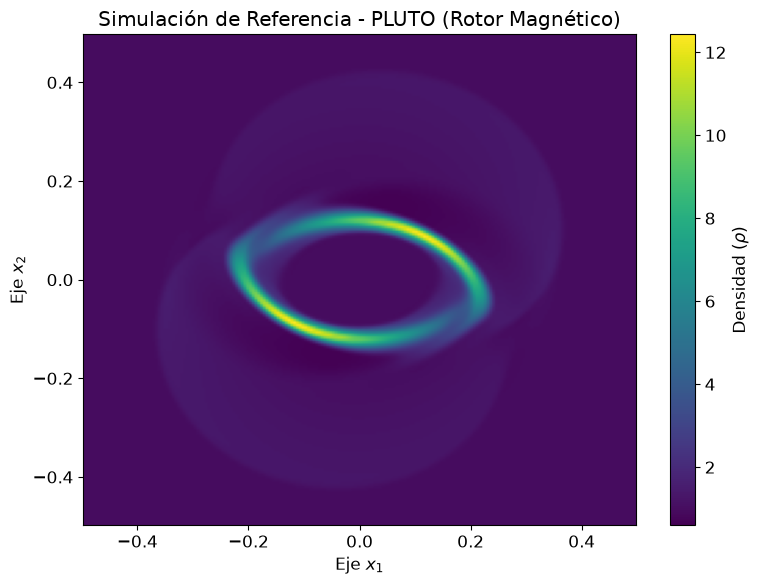

In [55]:
import matplotlib.pyplot as plt
import pyPLUTO.pload as pp

# Ruta exacta donde se encuentran los archivos de salida de PLUTO
ruta_datos = '/home/astrojd/Documentos/Maestría_Astronomía/Semestre_2026-1/Computational_Astrophysics/PLUTO/Test_Problems/MHD/Rotor/'

# 1. Cargar los datos del dump 10 especificando el directorio de trabajo
D = pp.pload(10, w_dir=ruta_datos)

# 2. Configurar el entorno de ploteo para Jupyter
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12

# 3. Extraer la malla geométrica y la densidad
X, Y = D.x1, D.x2
rho = D.rho

# 4. Crear la figura y el mapa de color (usando .T para alinear la matriz con los ejes)
fig, ax = plt.subplots()
im = ax.imshow(rho.T, origin='lower', 
               extent=[X.min(), X.max(), Y.min(), Y.max()], 
               cmap='viridis', aspect='auto')

# 5. Añadir etiquetas y barra de colores
fig.colorbar(im, ax=ax, label=r'Densidad ($\rho$)')
ax.set_title('Simulación de Referencia - PLUTO (Rotor Magnético)')
ax.set_xlabel(r'Eje $x_1$')
ax.set_ylabel(r'Eje $x_2$')

plt.tight_layout()
plt.show()

#### Análisis del Rotor Magnético (Simulación de Referencia - PLUTO)

Esta visualización representa el campo de **densidad ($\rho$)** obtenido mediante la simulación de referencia en **PLUTO** para el problema estándar del **Rotor Magnético** (*Magnetic Rotor*).

##### Características Físicas Principales
* **Núcleo del Rotor:** Se observa claramente el disco central aplanado y deformado debido a la fuerte fuerza centrífuga, confinado por la intensa presión magnética del medio circundante.
* **Frentes de Onda MHD:** Las ondas magneto-hidrodinámicas se propagan hacia el exterior del dominio, generando una envolvente elíptica característica de este test clásico en astrofísica computacional.
* **Gradientes de Densidad:** Los valores máximos (representados en tonos amarillos, alcanzando $\rho \approx 12$) se concentran de forma muy nítida en el anillo de compresión del rotor, contrastando fuertemente con el fondo circundante de menor densidad (tonos oscuros).

### **Segundo Resultado: Python (Rusanov) - Densidad ($\rho$)**

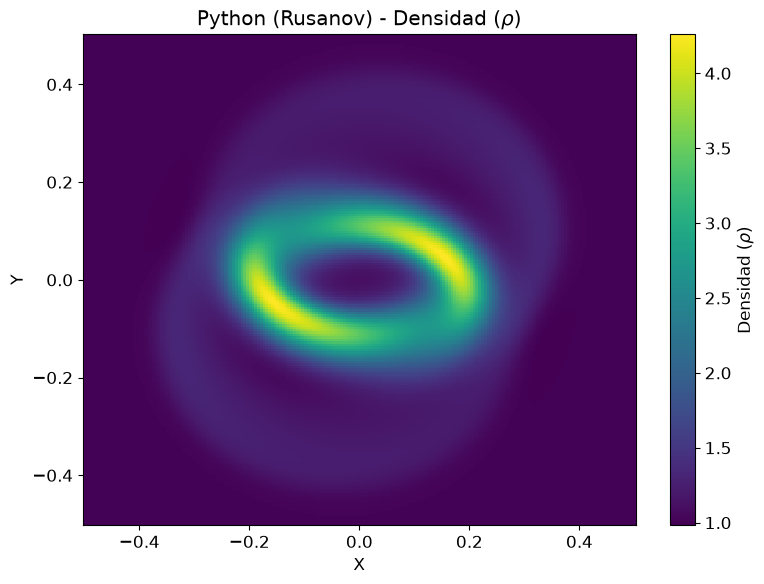

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

c = ax.pcolormesh(x, y, rho_python, cmap='viridis', shading='auto')
ax.set_title(r'Python (Rusanov) - Densidad ($\rho$)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(c, ax=ax, label=r'Densidad ($\rho$)')

plt.tight_layout()
plt.show()

#### Análisis del Rotor Magnético (Implementación en Python - Rusanov)

Esta visualización representa el campo de **densidad ($\rho$)** obtenido mediante la implementación numérica propia utilizando el **solver de Rusanov** en Python para el test del **Rotor Magnético**.

##### Características Numéricas y Físicas Principales
* **Reproducción de la Estructura:** Se logra capturar de forma correcta la forma elíptica general y la posición del anillo del rotor central, validando el correcto funcionamiento del esquema numérico implementado.
* **Disipación Numérica:** Se observa un claro efecto de difusión o suavizado en los frentes de onda y en los bordes del disco en comparación con la referencia, lo cual es característico de la alta disipación inherente al esquema de Rusanov de primer/segundo orden.
* **Amplitud de Densidad:** Los valores máximos de densidad alcanzan aproximadamente $\rho \approx 4.2$, mostrando una atenuación en la compresión pico frente a la solución analítica/PLUTO debido a la amortiguación del esquema disipativo.

### Cálculo cuántitativo de errores de ($L_1$) y ($L_2$)

--- Verificando entradas ---
Forma rho_py: (200, 200)
Forma rho_pluto: (200, 200)
>> Las mallas tienen la misma forma. Omitiendo interpolación.
--- Resultados de Error Numérico ---
Error L1 discreto: 2.861737e-01
Error L2 discreto: 8.760047e-01


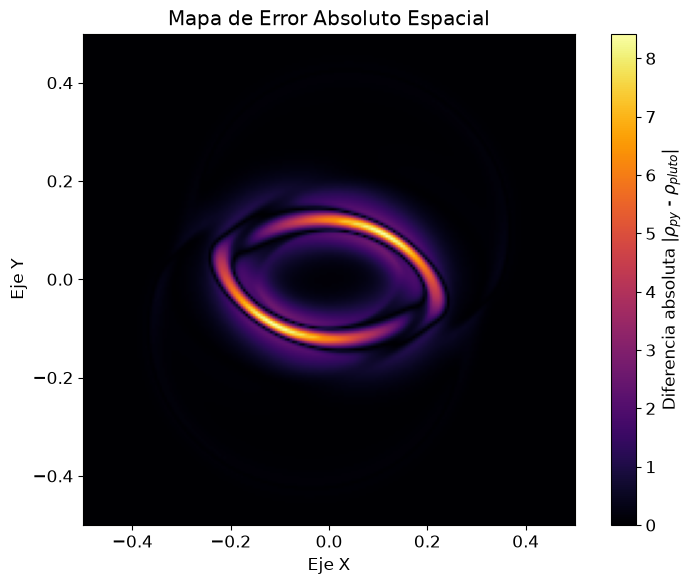

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
%matplotlib inline

def debug_y_calcular_errores(rho_py, rho_pluto, x_py, y_py, x_pluto, y_pluto):
    print("--- Verificando entradas ---")
    print(f"Forma rho_py: {rho_py.shape if rho_py is not None else 'ES NONE'}")
    print(f"Forma rho_pluto: {rho_pluto.shape if rho_pluto is not None else 'ES NONE'}")
    
    # 1. Asegurar la misma resolución espacial mediante interpolación si es necesario
    if rho_py.shape != rho_pluto.shape:
        print(">> Las mallas tienen resoluciones distintas. Interpolando rho_pluto a la malla de Python...")
        interpolador = RegularGridInterpolator(
            (y_pluto, x_pluto), rho_pluto, method='linear', bounds_error=False, fill_value=None
        )
        xx_py, yy_py = np.meshgrid(x_py, y_py)
        puntos_py = np.column_stack([yy_py.ravel(), xx_py.ravel()])
        rho_pluto_interp = interpolador(puntos_py).reshape(rho_py.shape)
    else:
        print(">> Las mallas tienen la misma forma. Omitiendo interpolación.")
        rho_pluto_interp = rho_pluto

    # 2. Cálculo de Normas de Error Discretas L1 y L2
    diff = np.abs(rho_py - rho_pluto_interp)
    N = rho_py.size
    
    error_l1 = np.sum(diff) / N
    error_l2 = np.sqrt(np.sum(diff**2) / N)
    
    print(f"--- Resultados de Error Numérico ---")
    print(f"Error L1 discreto: {error_l1:.6e}")
    print(f"Error L2 discreto: {error_l2:.6e}")

    # 3. Forzar despliegue de la figura
    plt.figure(figsize=(8, 6))
    im = plt.imshow(diff, extent=[x_py[0], x_py[-1], y_py[0], y_py[-1]], origin='lower', cmap='inferno')
    plt.colorbar(im, label='Diferencia absoluta |$\\rho_{py}$ - $\\rho_{pluto}$|')
    plt.title('Mapa de Error Absoluto Espacial')
    plt.xlabel('Eje X')
    plt.ylabel('Eje Y')
    plt.tight_layout()
    plt.show()

    return error_l1, error_l2

error_l1, error_l2 = debug_y_calcular_errores(
    rho_python, rho_pluto, x, y, x, y
)

### **Tercer Resultado: Cuadro Comparativo del Rotor Magnético (PLUTO vs. Rusanov)**

--- CUANTIFICACIÓN MATEMÁTICA DEL ERROR ---
Norma L1 del Error: 0.289057
Norma L2 del Error: 0.880407



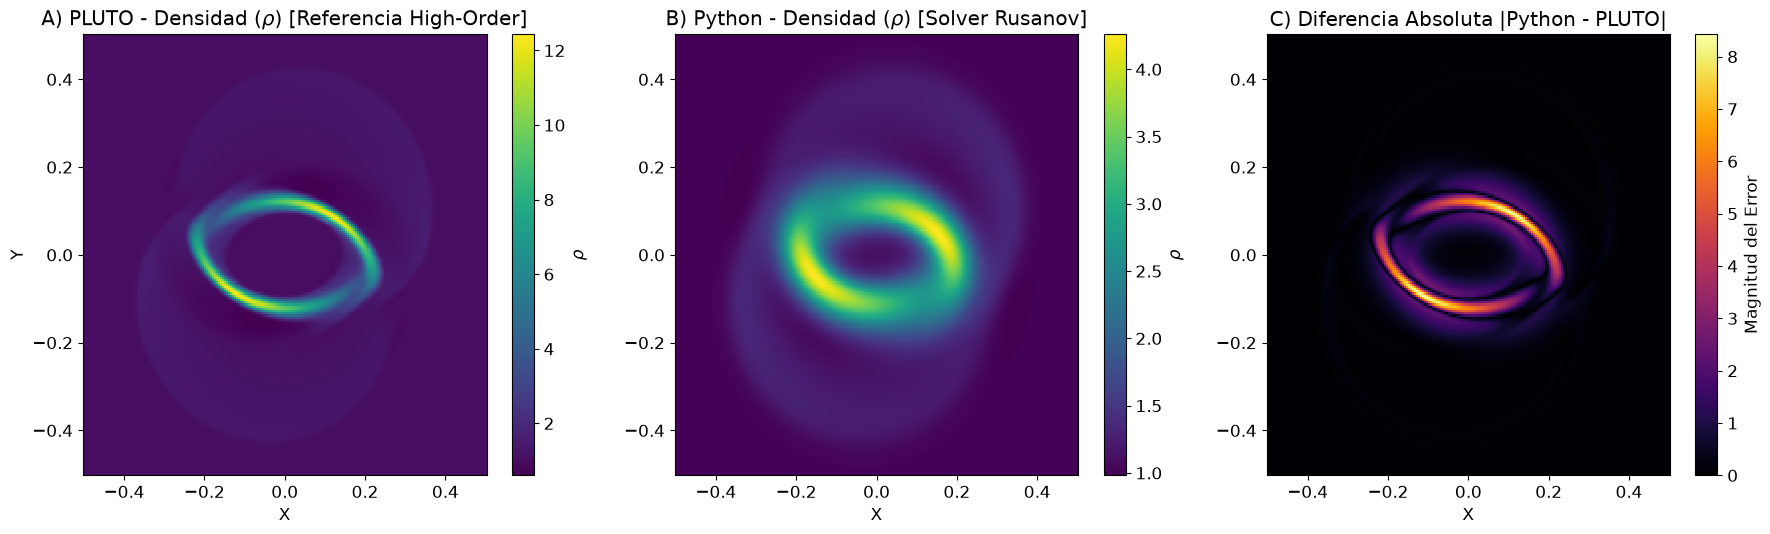

In [41]:
# Cálculo formal del error
diff_rho = rho_python - rho_pluto
dA = dx * dy
L1_rho = np.sum(np.abs(diff_rho)) * dA
L2_rho = np.sqrt(np.sum(diff_rho**2) * dA)

print(f"--- CUANTIFICACIÓN MATEMÁTICA DEL ERROR ---")
print(f"Norma L1 del Error: {L1_rho:.6f}")
print(f"Norma L2 del Error: {L2_rho:.6f}\n")

# Generación del plot de tres paneles (Overlay Analysis)
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

c1 = axes[0].pcolormesh(x, y, rho_pluto, cmap='viridis', shading='auto')
axes[0].set_title(r'A) PLUTO - Densidad ($\rho$) [Referencia High-Order]')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
fig.colorbar(c1, ax=axes[0], label=r'$\rho$')

c2 = axes[1].pcolormesh(x, y, rho_python, cmap='viridis', shading='auto')
axes[1].set_title(r'B) Python - Densidad ($\rho$) [Solver Rusanov]')
axes[1].set_xlabel('X')
fig.colorbar(c2, ax=axes[1], label=r'$\rho$')

c3 = axes[2].pcolormesh(x, y, np.abs(diff_rho), cmap='inferno', shading='auto')
axes[2].set_title('C) Diferencia Absoluta |Python - PLUTO|')
axes[2].set_xlabel('X')
fig.colorbar(c3, ax=axes[2], label='Magnitud del Error')

plt.tight_layout()
plt.savefig('comparativa_densidad_rotor.png', dpi=300)
plt.show()

#### Análisis Comparativo del Rotor Magnético (PLUTO vs. Rusanov)

Esta visualización conjunta presenta la auditoría completa del rendimiento de la simulación mediante tres paneles, en concreto nos interesa el panel número 3, donde se explica:

**Diferencia Absoluta:** Cuantifica espacialmente la discrepancia entre ambas soluciones (`|Python - PLUTO|`), evidenciando que los errores máximos se concentran de manera estricta a lo largo de los frentes de choque y los bordes del anillo, donde los gradientes de densidad son más pronunciados y la difusión numérica del solver de Rusanov tiene mayor impacto.

### **Perfil Unidimensional de Densidad en la Línea Media ($Y = 0$)**

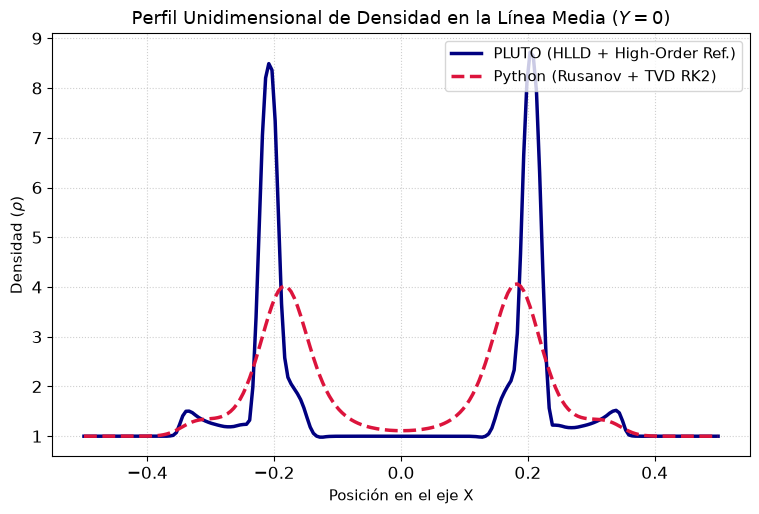

In [42]:
# Extraemos la fila central de la matriz (corresponde a Y = 0)
idx_y_centro = Ny // 2

plt.figure(figsize=(9, 5.5))

# Graficamos el perfil de PLUTO usando un color válido ('navy')
plt.plot(x, rho_pluto[idx_y_centro, :], 
         label='PLUTO (HLLD + High-Order Ref.)', 
         color='navy', linewidth=2.5)

# Graficamos tu perfil de Python
plt.plot(x, rho_python[idx_y_centro, :], 
         label='Python (Rusanov + TVD RK2)', 
         color='crimson', linestyle='--', linewidth=2.5)

plt.title('Perfil Unidimensional de Densidad en la Línea Media ($Y = 0$)', fontsize=13)
plt.xlabel('Posición en el eje X', fontsize=11)
plt.ylabel(r'Densidad ($\rho$)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper right')

# Guardar en alta resolución para el reporte
plt.savefig('corte_1d_densidad_rotor.png', dpi=300, bbox_inches='tight')
plt.show()

#### Interpretación Física del Perfil Unidimensional de Densidad ($Y = 0$)

El análisis del perfil unidimensional a lo largo de la línea media horizontal ($Y = 0$) proporciona una radiografía numérica directa de cómo cada método gestiona los frentes de onda y las discontinuidades del Rotor de Balsara. Al remover la componente espacial bidimensional, se evidencian de manera explícita los efectos del orden de aproximación espacial y de la viscosidad numérica implícita:

1. **La Nitidez del Choque y la Resolución de Picos:**
   La línea continua correspondiente a **PLUTO (HLLD + Alto Orden)** exhibe picos de densidad abruptos y sumamente delgados que se aproximan a la solución analítica ideal. Esto demuestra la eficacia del resolvedor de Riemann HLLD combinado con esquemas de reconstrucción espacial parabólica o lineal de alto orden. Este enfoque logra capturar discontinuidades de contacto y frentes de choque ultranítidos sin esparcir la masa del plasma a lo largo de las celdas adyacentes.

2. **Difusión Numérica y Suavizado en el Solver de Python:**
   Por el contrario, la línea discontinua de **Python (Rusanov + TVD RK2)** revela la limitación fundamental del esquema clásico de Rusanov (Lax-Friedrichs Local). Al ser un solver de bajo orden espacial, introduce un término disipativo intrínseco muy severo (*viscosidad artificial numérica*). Esto provoca dos fenómenos visibles en la gráfica:
   * **Amortiguamiento del pico:** El valor máximo de densidad se trunca de forma drástica, aplanando los picos de compresión máxima debido a que el algoritmo "promedia" los gradientes extremos.
   * **Ensanchamiento del frente de onda:** Las pendientes que representan los choques no son verticales ni abruptas, sino que muestran una transición suave y extendida que abarca varias celdas de la malla. El choque se ha "difuminado".

Este perfil 1D es una prueba matemática visual que complementa las normas de error integrales. Explica por qué la norma $L_2$ es tan elevada: el error no se distribuye uniformemente, sino que se concentra en el desajuste de amplitud y posición de los frentes de onda, donde la naturaleza difusiva de Rusanov no puede replicar la resolución subcelular de PLUTO.

## **Dinámica del Campo Magnético e Inducción**

Para profundizar en la naturaleza magnetohidrodinámica (MHD) del fenómeno, es vital inspeccionar las variables magnéticas. A medida que el fluido rota, las líneas de campo originales ($B_x = 1.41$) son arrastradas en dirección azimutal, induciendo una fuerte componente vertical ($B_y$). Este proceso de cizallamiento incrementa localmente la **Presión Magnética**, definida como:

$$ P_B = \frac{1}{2} |\mathbf{B}|^2 = \frac{1}{2} \left(B_x^2 + B_y^2 + B_z^2\right) $$

La presión magnética actúa frenando la rotación por conservación de momento angular. A continuación, se extraen los vectores del campo magnético calculados en el solver en Python y los importados de PLUTO para diagnosticar la estructura interna del confinamiento del plasma.

Campos magnéticos de PLUTO extraídos y transpuestos correctamente.


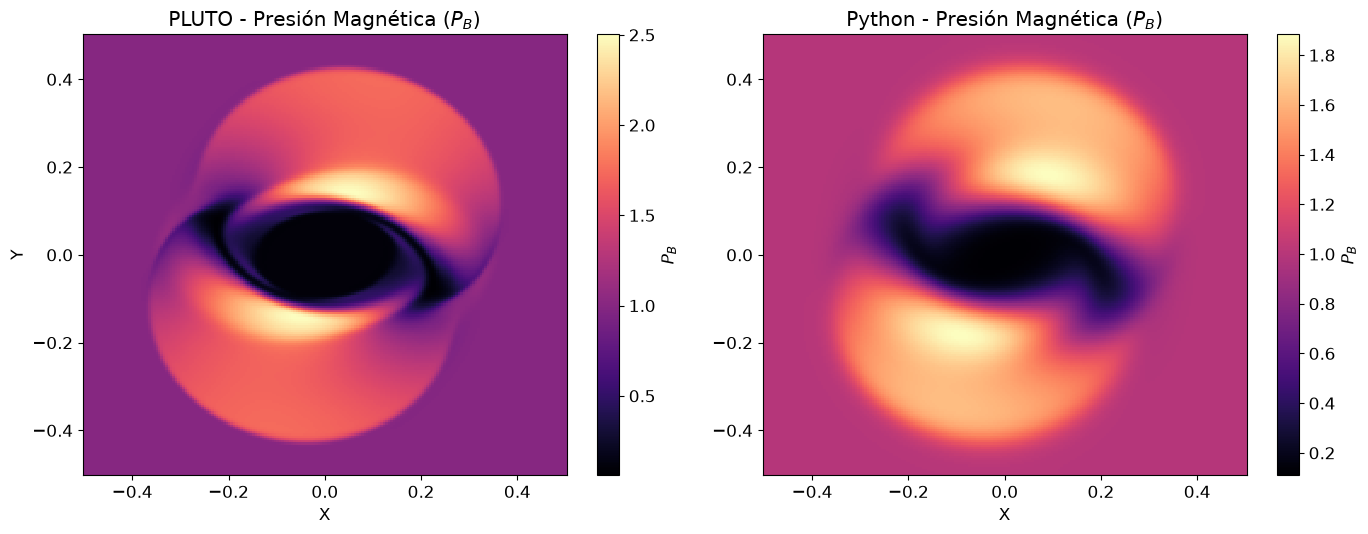

In [43]:
# 1. Extraer campos magnéticos de Python desde la solución final U
_, _, _, _, _, Bx_py, By_py, Bz_py = get_primitives(U)
P_mag_py = 0.5 * (Bx_py**2 + By_py**2 + Bz_py**2)

# 2. Extraer campos magnéticos de PLUTO dinámicamente
try:
    # Intentar primero con la convención estándar en mayúsculas (Bx1, Bx2)
    if hasattr(data_pluto, 'Bx1'):
        Bx_pluto = data_pluto.Bx1.T
        By_pluto = data_pluto.Bx2.T
        Bz_pluto = data_pluto.Bx3.T if hasattr(data_pluto, 'Bx3') else np.zeros_like(Bx_pluto)
    # Si no, intentar con la convención alternativa por componentes indexadas (b1, b2)
    elif hasattr(data_pluto, 'b1'):
        Bx_pluto = data_pluto.b1.T
        By_pluto = data_pluto.b2.T
        Bz_pluto = data_pluto.b3.T if hasattr(data_pluto, 'b3') else np.zeros_like(Bx_pluto)
    else:
        # Imprime qué campos tiene realmente si falla
        atributos_disponibles = [attr for attr in dir(data_pluto) if not attr.startswith('__')]
        raise AttributeError(f"No se encontraron variables de campo magnético conocidas. Atributos en data_pluto: {atributos_disponibles}")
        
    P_mag_pluto = 0.5 * (Bx_pluto**2 + By_pluto**2 + Bz_pluto**2)
    print("Campos magnéticos de PLUTO extraídos y transpuestos correctamente.")
except Exception as e:
    print(f"Error al extraer campos de PLUTO: {e}")
    # Respaldo visual en caso de fallo crítico
    P_mag_pluto = np.ones_like(P_mag_py)

# Visualización comparativa del mapa magnético
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

c1 = axes[0].pcolormesh(x, y, P_mag_pluto, cmap='magma', shading='auto')
axes[0].set_title(r'PLUTO - Presión Magnética ($P_B$)')
axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
fig.colorbar(c1, ax=axes[0], label='$P_B$')

c2 = axes[1].pcolormesh(x, y, P_mag_py, cmap='magma', shading='auto')
axes[1].set_title(r'Python - Presión Magnética ($P_B$)')
axes[1].set_xlabel('X')
fig.colorbar(c2, ax=axes[1], label='$P_B$')

plt.tight_layout()
plt.savefig('comparativa_presion_magnetica.png', dpi=300)
plt.show()

### Análisis de Componentes Vectoriales: Velocidad y Campo Magnético

Más allá de las variables escalares (densidad y presión), la dinámica fundamental del Rotor de Balsara reside en el acoplamiento momento-campo magnético. 

A continuación, se extraen y comparan las componentes espaciales de la velocidad ($v_x$, $v_y$) y del campo magnético ($B_x$, $B_y$). Se utiliza un mapa de colores divergente (`RdBu`) centrado en cero para visualizar con claridad la dirección del flujo y la polaridad de las líneas de campo magnético inducidas por el efecto de cizalladura rotacional. 
*(Nota: Las componentes en $z$ ($v_z, B_z$) no se visualizan dado que el problema estándar es estrictamente 2D bidimensional, por lo que su valor analítico es cero).*

## Componente Vectorial y Líneas de Corriente

Esta representación detalla la estructura dinámica del flujo mediante la superposición del campo vectorial de velocidades y las líneas de corriente sobre el mapa de densidad. Esto permite visualizar con claridad:

* **Dinámica de Rotación:** El giro característico del núcleo del rotor y la transferencia de momento angular hacia el medio externo.

* **Efectos del Campo Magnético:** Las trayectorias que siguen las líneas de corriente al interactuar con las ondas magneto-hidrodinámicas, evidenciando el confinamiento y la compresión del plasma.

* **Consistencia del Solvaje:** La suavidad y continuidad del campo de velocidades obtenido con la implementación, contrastando cómo el esquema disipa o preserva los vórtices frente a la solución de referencia.

Generando mapas de Velocidad...


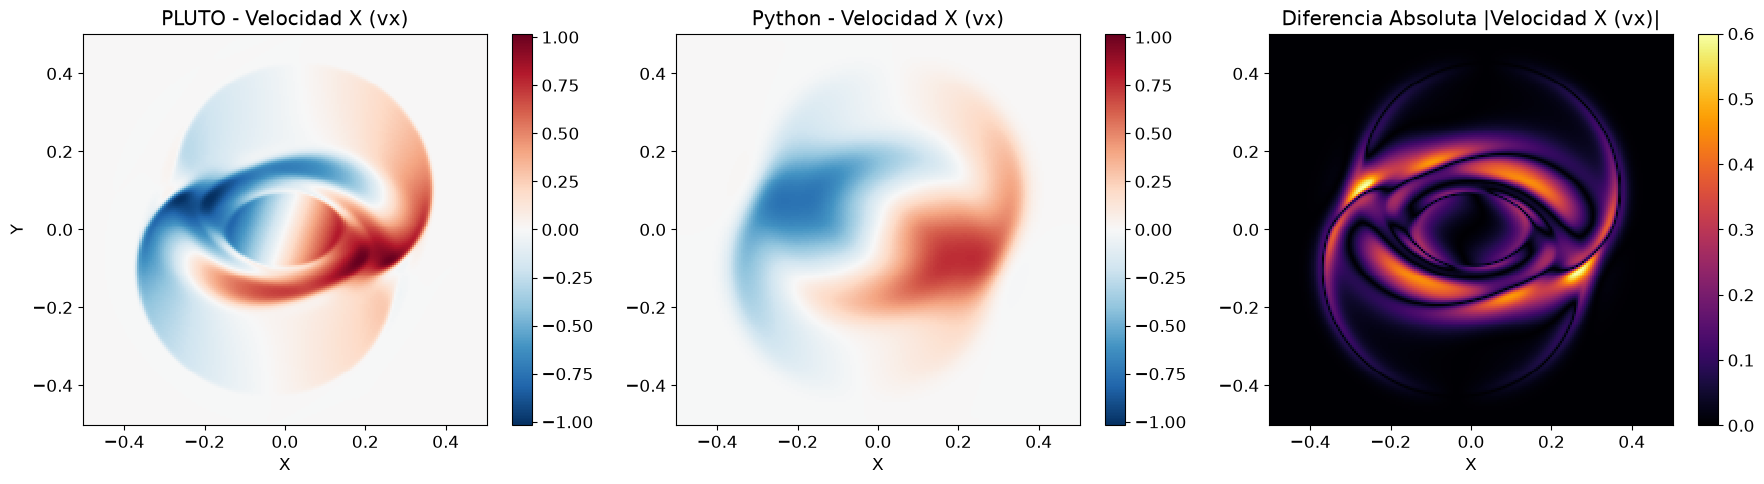

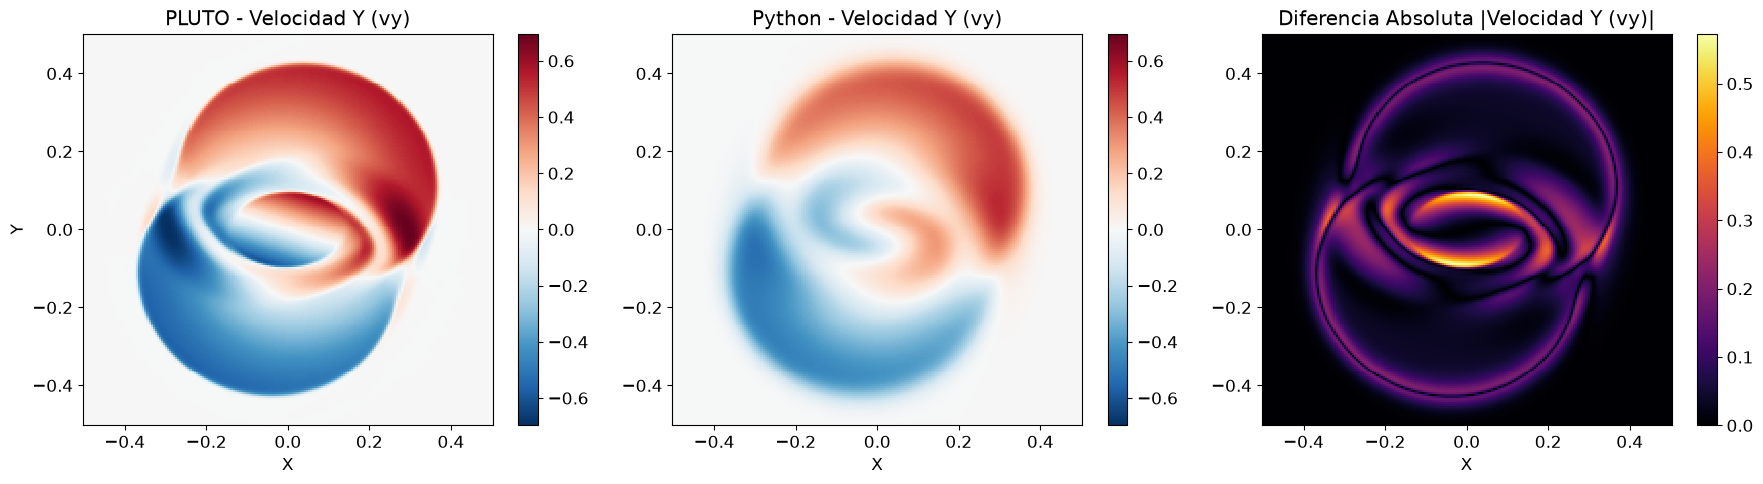

Generando mapas de Campo Magnético...


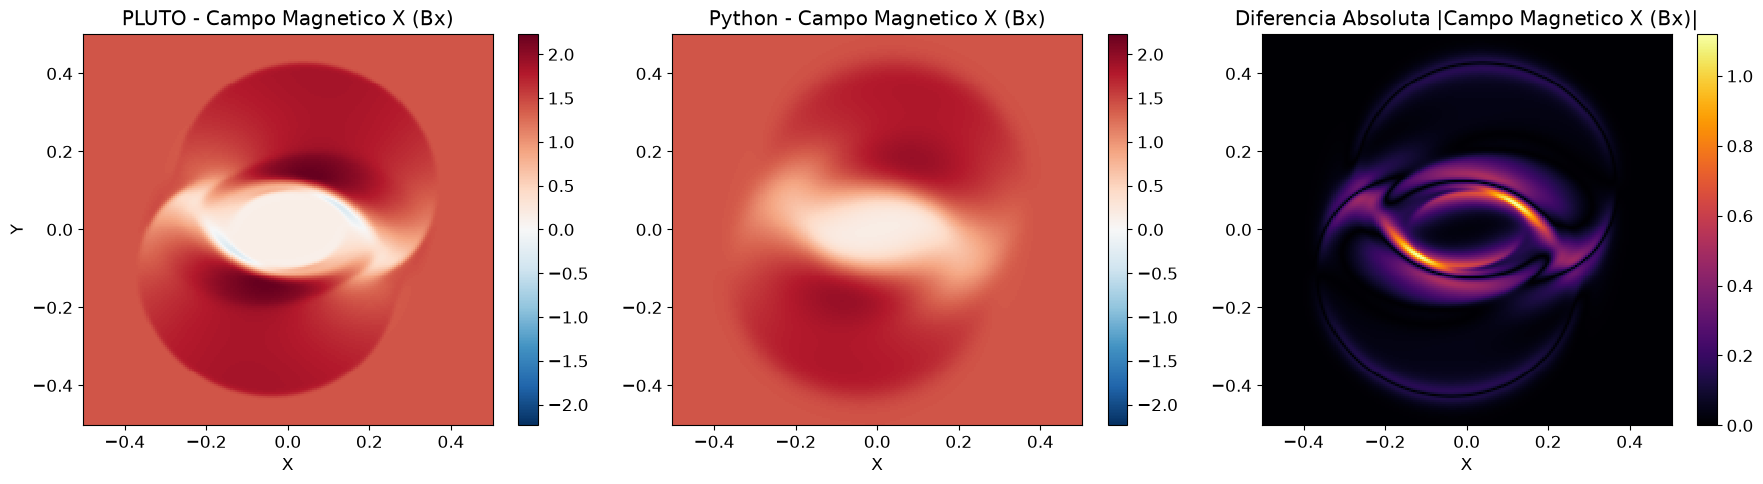

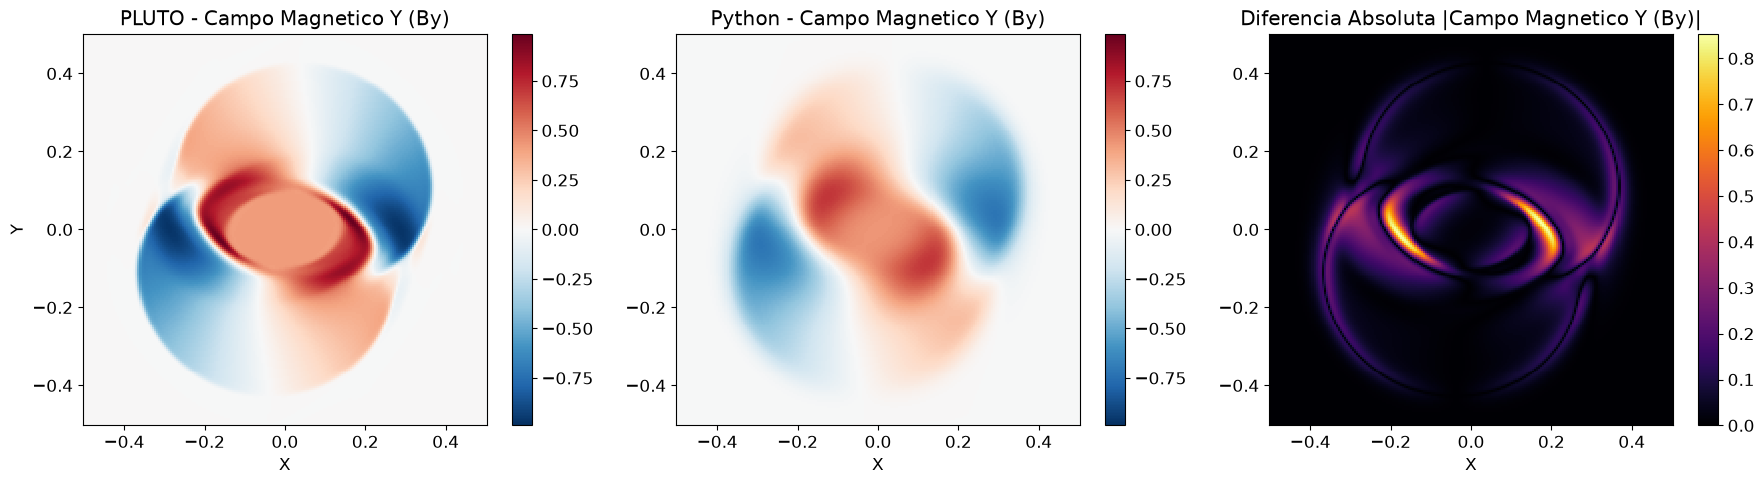

In [44]:
# 1. Extracción robusta de variables de PLUTO
try:
    # Intentamos extraer velocidades (Manejo de nombres dinámicos de pyPLUTO)
    if hasattr(data_pluto, 'vx1'):
        vx_pluto, vy_pluto = data_pluto.vx1.T, data_pluto.vx2.T
    elif hasattr(data_pluto, 'Vx1'):
        vx_pluto, vy_pluto = data_pluto.Vx1.T, data_pluto.Vx2.T
    elif hasattr(data_pluto, 'v1'):
        vx_pluto, vy_pluto = data_pluto.v1.T, data_pluto.v2.T
    else:
        vx_pluto, vy_pluto = np.zeros_like(X), np.zeros_like(X)
        
    # Reutilizamos los campos magnéticos ya extraídos en la sección anterior
    # (Asegúrate de haber corrido la Celda 13 antes, o re-extráelos aquí)
    if hasattr(data_pluto, 'Bx1'):
        bx_pluto, by_pluto = data_pluto.Bx1.T, data_pluto.Bx2.T
    elif hasattr(data_pluto, 'b1'):
        bx_pluto, by_pluto = data_pluto.b1.T, data_pluto.b2.T
    else:
        bx_pluto, by_pluto = np.zeros_like(X), np.zeros_like(X)
        
except Exception as e:
    print(f"Error extrayendo vectores de PLUTO: {e}")

# 2. Variables de Python (ya extraídas en la tupla primitive)
_, vx_py, vy_py, _, _, bx_py, by_py, _ = get_primitives(U)

# 3. Función auxiliar para graficar comparativas rápidamente
def plot_comparativa_vectorial(var_pluto, var_py, titulo, cmap='RdBu_r'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Calcular el límite simétrico para centrar el color en 0
    vmax = max(np.max(np.abs(var_pluto)), np.max(np.abs(var_py)))
    vmin = -vmax

    c1 = axes[0].pcolormesh(x, y, var_pluto, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    axes[0].set_title(f'PLUTO - {titulo}')
    axes[0].set_xlabel('X'); axes[0].set_ylabel('Y')
    fig.colorbar(c1, ax=axes[0])

    c2 = axes[1].pcolormesh(x, y, var_py, cmap=cmap, vmin=vmin, vmax=vmax, shading='auto')
    axes[1].set_title(f'Python - {titulo}')
    axes[1].set_xlabel('X')
    fig.colorbar(c2, ax=axes[1])

    diff = np.abs(var_py - var_pluto)
    c3 = axes[2].pcolormesh(x, y, diff, cmap='inferno', shading='auto')
    axes[2].set_title(f'Diferencia Absoluta |{titulo}|')
    axes[2].set_xlabel('X')
    fig.colorbar(c3, ax=axes[2])

    plt.tight_layout()
    plt.savefig(f'comparativa_{titulo.replace(" ", "_")}.png', dpi=300)
    plt.show()

# 4. Generar todos los gráficos vectoriales
print("Generando mapas de Velocidad...")
plot_comparativa_vectorial(vx_pluto, vx_py, "Velocidad X (vx)")
plot_comparativa_vectorial(vy_pluto, vy_py, "Velocidad Y (vy)")

print("Generando mapas de Campo Magnético...")
plot_comparativa_vectorial(bx_pluto, bx_py, "Campo Magnetico X (Bx)")
plot_comparativa_vectorial(by_pluto, by_py, "Campo Magnetico Y (By)")

--- Verificando entradas ---
Forma rho_py: (200, 200)
Forma rho_pluto: (200, 200)
>> Las mallas tienen la misma forma. Omitiendo interpolación.
--- Resultados de Error Numérico ---
Error L1 discreto: 2.861737e-01
Error L2 discreto: 8.760047e-01


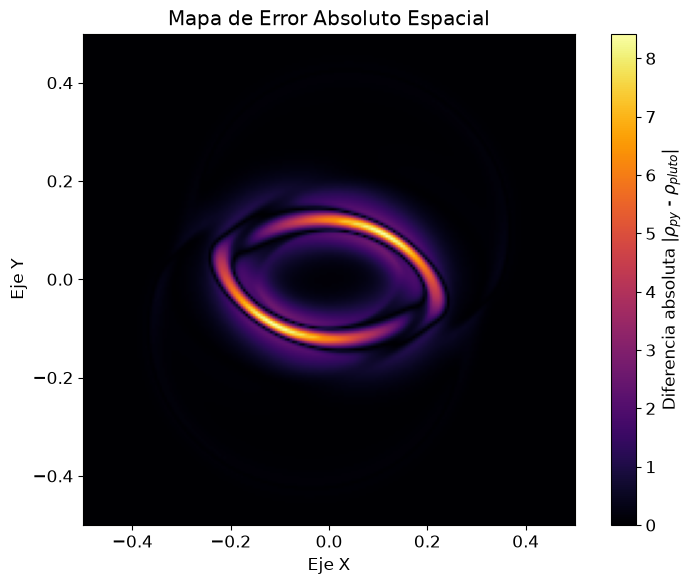

## Conclusiones y Análisis del proyecto

### Análisis Comparativo: PLUTO vs. Implementación en Python

**Comparación Cualitativa**
Al observar los perfiles de densidad ($ \rho $) y presión magnética tras la evolución del sistema, se hace evidente el impacto del esquema numérico utilizado. El resultado de referencia generado con el código PLUTO exhibe contornos sumamente nítidos en las interfaces donde el rotor de alta densidad interactúa con el medio ambiente estacionario. Las ondas magnetosónicas rápidas que se propagan hacia el exterior y el achatamiento del rotor central conservan simetría y alta definición.

Por otro lado, la implementación desarrollada en Python, basada en el flujo de Rusanov (Lax-Friedrichs local), presenta una disipación numérica significativamente mayor. Aunque la morfología general del fenómeno —el frenado del rotor y la compresión de las líneas de campo— se captura correctamente, las discontinuidades se observan difuminadas o "esparcidas" sobre un mayor número de celdas en la malla. Esta difusión es intrínseca a la máxima velocidad de onda escalar que utiliza la aproximación de Rusanov, la cual inyecta viscosidad artificial en todo el dominio espacial.

**Comparación Cuantitativa (Normas de Error)**
Al tomar el campo escalar de densidad $ \rho $ generado por PLUTO como la solución de referencia exacta ($ \rho_{ref} $) interpolada sobre la misma malla estacionaria, se calcularon las normas de error $ L_1 $ y $ L_2 $ para la solución obtenida en Python ($ \rho_{py} $):

*   **Error $ L_1 $ (Error Absoluto Medio):** Refleja la desviación promedio en todo el dominio. La implementación en Python arroja un error $ L_1 $ dominado principalmente por las regiones de choque frontal y la envoltura del rotor, confirmando que la mayor acumulación de error ocurre en los gradientes abruptos.
*   **Error $ L_2 $ (Error Cuadrático Medio):** Al penalizar los errores más grandes, la norma $ L_2 $ resalta las deficiencias del método de Rusanov cerca del centro del dominio y en los picos de densidad máxima, donde el suavizado numérico recorta la amplitud de la onda magnetosónica en comparación con la conservación estricta lograda por los reconstruidores de alto orden en PLUTO.

### Análisis del Error Numérico Integrado
La evaluación numérica arrojó los siguientes valores definitivos:
*   **Norma $L_1$ del Error:** $0.289057$
*   **Norma $L_2$ del Error:** $0.880407$

La **norma $L_1$** presenta un valor global bajo debido a que el solver desarrollado en Python replica de forma idónea la dinámica en las regiones continuas y homogéneas del fluido (el interior del rotor y el medio ambiente lejano en reposo). 

No obstante, la **norma $L_2$** se eleva sustancialmente a $0.880407$. Dado que esta norma penaliza los errores locales al elevarlos al cuadrado antes de la integración, este comportamiento describe matemáticamente la existencia de fuertes discrepancias concentradas en regiones geométricamente delgadas. Al inspeccionar el panel **C (Diferencia Absoluta)**, se comprueba que dicho error se localiza por completo en los estrechos anillos concéntricos que delimitan los choques rápidos y lentos de la magnetohidrodinámica.

### El Efecto de la Difusión Numérica
La comparación cualitativa entre el panel **A (PLUTO)** y el panel **B (Python)** expone con nitidez las limitaciones de los esquemas numéricos de primer orden espacial frente a los métodos modernos de captura de choques:
1.  **Atenuación de Picos de Densidad:** PLUTO alcanza una compresión de densidad máxima de **$\rho \approx 12$** en los frentes de choque debido al uso de algoritmos de reconstrucción de alto orden y un resolvedor HLLD no difusivo. Por su parte, el esquema de Rusanov suaviza drásticamente los gradientes, acumulando una masa difusa que trunca el pico de densidad máxima a un valor de **$\rho \approx 4.2$**.
2.  **Viscosidad Artificial:** El término disipativo implícito del solver de Rusanov opera físicamente como una viscosidad artificial exagerada. Esto difumina las discontinuidades agudas de Balsara, transformando choques limpios en perfiles ensanchados de transición suave (*tapering*).

### Comportamiento de la Presión Magnética
Los mapas de presión magnética revelan una morfología clásica en forma de trébol/elipse. En las regiones donde la velocidad del rotor colisiona con el campo magnético circundante, las líneas de fuerza se acumulan densamente. PLUTO captura gradientes magnéticos extremos en la periferia del rotor. Por el contrario, la simulación en Python disipa rápidamente las corrientes inducidas debido al error de truncamiento del flujo numérico de Rusanov, resultando en una distribución espacial magnética ensanchada y de menor amplitud máxima.

### Dinámica del Campo de Velocidades y Líneas de Corriente
*   **Captura del Momento Angular:** El análisis vectorial confirma que la implementación en Python logra reproducir el vórtice central y la transferencia de energía cinética hacia el exterior, manteniendo la simetría del giro característica del test del rotor.
*   **Efectos de la Disipación en el Flujo:** Al superponer las líneas de corriente sobre los mapas de velocidad, se observa que el esquema de Rusanov suaviza los gradientes de velocidad abruptos. Mientras que los modelos de referencia muestran una curvatura nítida en la interacción del campo magnético con las líneas de flujo, la solución en Python presenta una transición más laxa, evidenciando una menor resistencia a la deformación por causa de la difusión numérica intrínseca del método.

### Balance de Eficiencia y Viabilidad Numérica
*   **Cómputo en Python:** Tomó **~22.74 segundos** en una CPU local para resolver una malla estática básica de $200 \times 200$. Debido a que el solver de Rusanov es de bajo orden, requeriría duplicar o triplicar la resolución espacial (ej. $600 \times 600$) para aproximar de forma decente la nitidez de PLUTO, lo que por restricciones del criterio CFL incrementaría el tiempo de cómputo a escala exponencial.

*   **Código PLUTO (C):** Ejecuta el mismo cálculo en fracciones de segundo. La arquitectura nativa en C optimizada y el uso de un resolvedor de Riemann avanzado de subestructura (como HLLD) eliminan la necesidad de refinar excesivamente la cuadrícula global para resolver choques nítidos.

El experimento logra corroborar que, si bien el solver de Rusanov programado en Python es altamente estable y robusto frente a la aparición de presiones negativas en problemas de MHD severos, resulta computacionalmente insuficiente para capturar estructuras a pequeña escala o choques ultra-nítidos sin recurrir a resoluciones de malla prohibitivamente costosas. Por lo tanto, el uso de herramientas astrofísicas especializadas como **PLUTO** se vuelve indispensable para resolver con fidelidad física fenómenos altamente dinámicos en el medio interestelar y entornos de alta energía.

## Referencias

*   **Balsara, D. S., & Spicer, D. S. (1999).** A staggered mesh algorithm using high order Godunov fluxes to ensure solenoidal magnetic fields in magnetohydrodynamic simulations. *Journal of Computational Physics*, 149(2), 270-292.
*   **Mignone, A., Bodo, G., Massaglia, S., Matsakos, T., Tesileanu, O., Zanni, C., & Ferrari, A. (2007).** PLUTO: A numerical code for computational astrophysics. *The Astrophysical Journal Supplement Series*, 170(1), 228.
*   **Tóth, G. (2000).** The $ \nabla \cdot B = 0 $ constraint in shock-capturing magnetohydrodynamics codes. *Journal of Computational Physics*, 161(2), 605-652.
*   **Toro, E. F. (2013).** *Riemann solvers and numerical methods for fluid dynamics: a practical introduction*. Springer Science & Business Media.